In [1]:
#Attention Heatmap
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


In [2]:
class AttentionLayer(tf.keras.layers.Layer):
    def call(self, encoder_outputs, decoder_hidden):
        score = tf.matmul(decoder_hidden, encoder_outputs, transpose_b=True)
        attention_weights = tf.nn.softmax(score, axis=-1)
        context_vector = tf.matmul(attention_weights, encoder_outputs)
        return context_vector, attention_weights


In [3]:
# Dummy data
encoder_outputs = tf.random.normal((1, 10, 64))
decoder_hidden = tf.random.normal((1, 1, 64))

attention = AttentionLayer()
context, weights = attention(encoder_outputs, decoder_hidden)

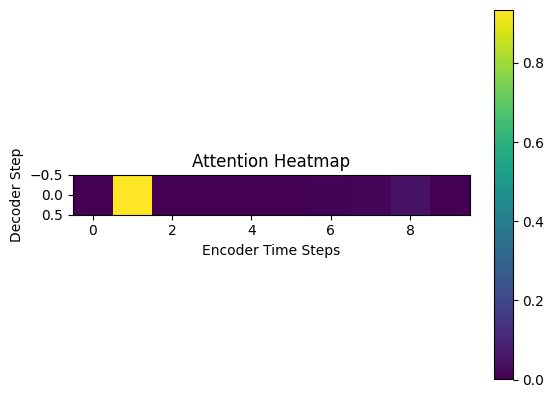

In [4]:
# Plot heatmap
weights = weights.numpy().reshape(1, -1)
plt.imshow(weights, cmap='viridis')
plt.colorbar()
plt.title("Attention Heatmap")
plt.xlabel("Encoder Time Steps")
plt.ylabel("Decoder Step")
plt.show()